# 1. Khám phá dữ liệu (EDA)

**Input:** `data/train.csv`, `data/test.csv`  
**Output:** `exps/data/data_EDA.csv`, `exps/data/columns_dtype.json` (dùng cho 2.pre-processing)

BEGIN

In [31]:
%reload_ext autoreload
%autoreload 2

In [32]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [33]:
MEMBER   = "TV1"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "EDA1"

seed_everything()

## VIỆC CỦA TV1 (EDA mở rộng cho báo cáo Chương 2)
- Đọc paper De Cock (doc/README.md): nguồn dữ liệu, ý nghĩa biến, khuyến nghị về ngoại lai.
- Thêm phân tích: SalePrice theo Neighborhood (boxplot), theo OverallQual; tương quan giữa các biến (đa cộng tuyến).
- Với **mỗi** cột thiếu dữ liệu, tra `data_description.txt`: NaN là *“không có”* hay *thiếu thật*? → lập bảng, chuyển cho pre-processing1.

## 1.1. Đọc dữ liệu

In [34]:
train, test = load_raw()
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (1460, 81) | test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1.2. Biến mục tiêu SalePrice
Giá lệch phải mạnh; Kaggle chấm RMSE trên **log(giá)** -> mọi mô hình học trên `log1p(SalePrice)`.

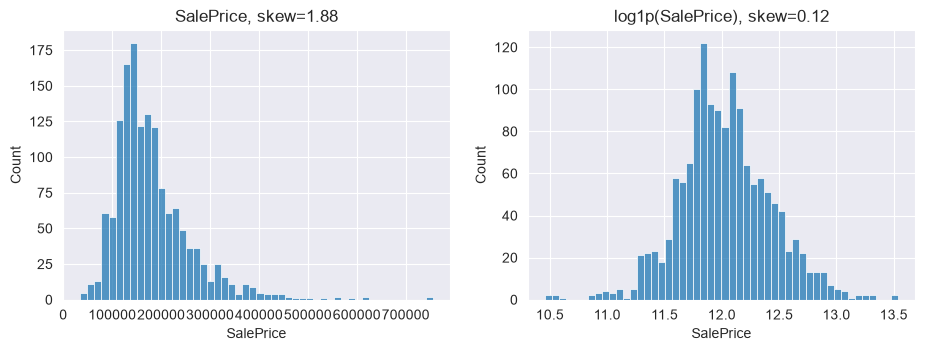

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(train.SalePrice, bins=50, ax=ax[0]).set_title(f'SalePrice, skew={train.SalePrice.skew():.2f}')
sns.histplot(np.log1p(train.SalePrice), bins=50, ax=ax[1]).set_title(f'log1p(SalePrice), skew={np.log1p(train.SalePrice).skew():.2f}')
plt.show()

## 1.3. Dữ liệu thiếu
Đối chiếu `data/data_description.txt`: nhiều NaN mang nghĩa **“không có”** (không gara, không hầm...).

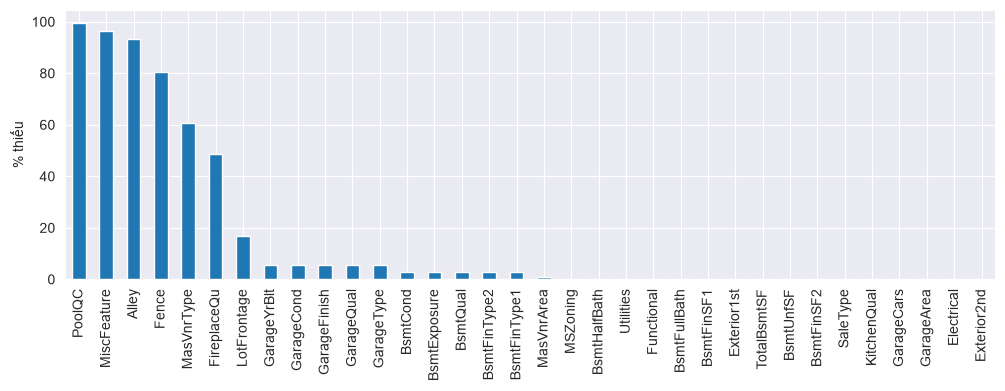

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu,LotFrontage,GarageYrBlt,GarageCond,GarageFinish,GarageQual,GarageType,BsmtCond,BsmtExposure,BsmtQual,BsmtFinType2,BsmtFinType1,MasVnrArea,MSZoning,BsmtHalfBath,Utilities,Functional,BsmtFullBath,BsmtFinSF1,Exterior1st,TotalBsmtSF,BsmtUnfSF,BsmtFinSF2,SaleType,KitchenQual,GarageCars,GarageArea,Electrical,Exterior2nd
% thiếu,99.7,96.4,93.2,80.4,60.5,48.6,16.6,5.4,5.4,5.4,5.4,5.4,2.8,2.8,2.8,2.7,2.7,0.8,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
full = pd.concat([train.drop(columns='SalePrice'), test])
miss = (full.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
miss.plot.bar(figsize=(12, 3.5), ylabel='% thiếu'); plt.show()
miss.round(1).to_frame('% thiếu').T

## 1.4. Tương quan với SalePrice

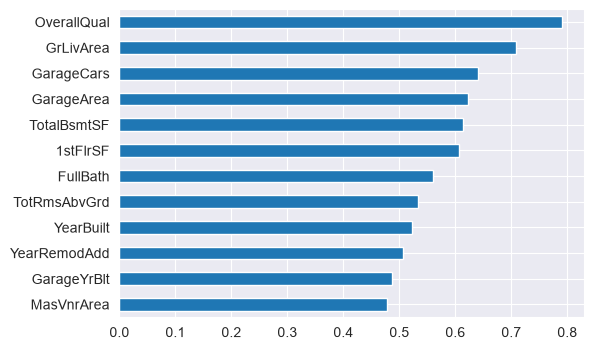

In [37]:
corr = train.select_dtypes('number').corr()['SalePrice'].drop(['SalePrice', 'Id'])
top = corr.abs().sort_values(ascending=False).head(12).index
corr[top][::-1].plot.barh(figsize=(6, 4)); plt.show()

## 1.5. Ngoại lai
Paper De Cock (2011) khuyến nghị xem xét các căn `GrLivArea > 4000`.

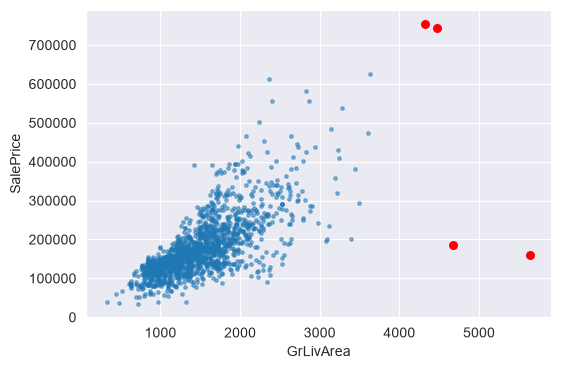

,GrLivArea,SalePrice,SaleCondition
523,4676,184750,Partial
691,4316,755000,Normal
1182,4476,745000,Abnorml
1298,5642,160000,Partial


In [38]:
out = train.GrLivArea > 4000
plt.figure(figsize=(6, 4))
plt.scatter(train.GrLivArea, train.SalePrice, s=6, alpha=.5)
plt.scatter(train.GrLivArea[out], train.SalePrice[out], s=30, c='red')
plt.xlabel('GrLivArea'); plt.ylabel('SalePrice'); plt.show()
train.loc[out, ['GrLivArea', 'SalePrice', 'SaleCondition']]

## 1.6. Lưu output cho stage sau

In [39]:
df = pd.concat([train.assign(is_train=1), test.assign(is_train=0)], ignore_index=True)
feat = [c for c in train.columns if c not in ('Id', 'SalePrice')]
numeric_columns  = train[feat].select_dtypes('number').columns.tolist()
category_columns = [c for c in feat if c not in numeric_columns]
df.to_csv(f'{exps_data}/data_EDA.csv', index=False)
with open(f'{exps_data}/columns_dtype.json', 'w') as f:
    json.dump({'numeric_columns': numeric_columns, 'category_columns': category_columns}, f, indent=1)
print(len(numeric_columns), 'cột số |', len(category_columns), 'cột phân loại ->', exps_data)

36 cột số | 43 cột phân loại -> d:/HocSau/House_Prices/house_prices_project/exps/data


## 1.7. Phân tích bổ sung

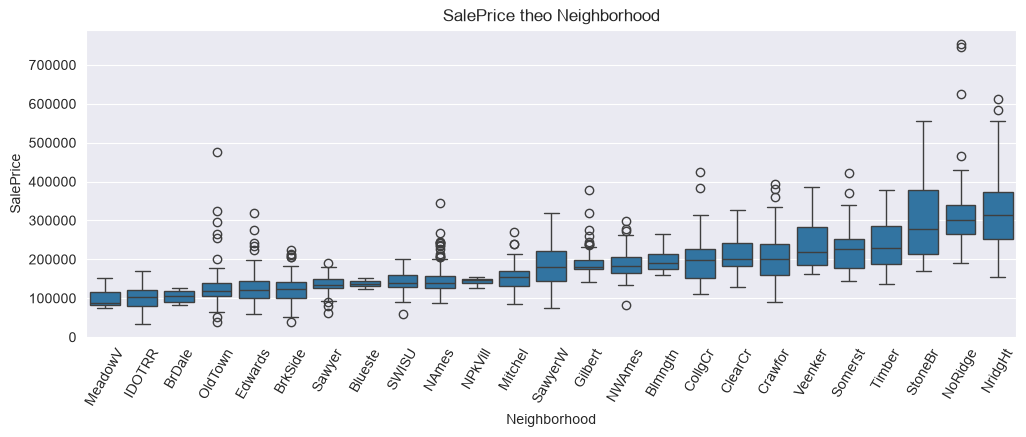

In [40]:
# 1) Giá theo khu dân cư (sắp theo trung vị)
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
plt.figure(figsize=(12, 4))
sns.boxplot(data=train, x='Neighborhood', y='SalePrice', order=order)
plt.xticks(rotation=60); plt.title('SalePrice theo Neighborhood'); plt.show()

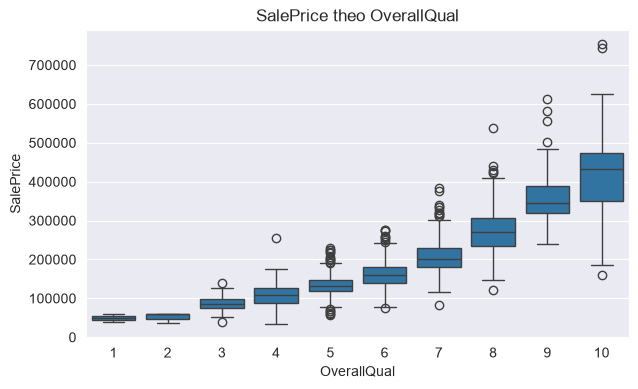

In [41]:
# 2) Giá theo chất lượng tổng thể
plt.figure(figsize=(7, 4))
sns.boxplot(data=train, x='OverallQual', y='SalePrice'); plt.title('SalePrice theo OverallQual'); plt.show()

In [42]:
# 3) Bảng cột thiếu dữ liệu + ý nghĩa NaN (cột "y_nghia" tự điền sau khi tra data_description.txt)
full = pd.concat([train.drop(columns='SalePrice'), test])
miss = full.isna().sum()
miss_tbl = pd.DataFrame({'so_o_thieu': miss[miss > 0],
                         'ti_le_%': (full.isna().mean()[miss > 0] * 100).round(1),
                         'kieu': full.dtypes[miss > 0].astype(str)}).sort_values('so_o_thieu', ascending=False)
miss_tbl['y_nghia'] = ''
miss_tbl

,so_o_thieu,ti_le_%,kieu,y_nghia
PoolQC,2909,99.7,str,
MiscFeature,2814,96.4,str,
Alley,2721,93.2,str,
Fence,2348,80.4,str,
MasVnrType,1766,60.5,str,
FireplaceQu,1420,48.6,str,
LotFrontage,486,16.6,float64,
GarageQual,159,5.4,str,
GarageYrBlt,159,5.4,float64,
GarageCond,159,5.4,str,


### Kết luận
- Giá lệch phải (skew 1,88) nên dùng log1p. Giá phụ thuộc mạnh vào vị trí: trung vị cao nhất ở NridgHt, NoRidge, StoneBr (≈ 280–315 nghìn USD), thấp nhất ở MeadowV, IDOTRR, BrDale (≈ 88–106 nghìn USD); giá tăng đều theo OverallQual (trung vị từ 50 nghìn ở mức 1 lên 432 nghìn ở mức 10). Phần lớn NaN mang nghĩa “không có” theo data_description.